<a href="https://colab.research.google.com/github/yadavkhushnoor-ai/ml-/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Step 2: Load dataset
# Upload your Titanic CSV file in Colab first
data = pd.read_csv('/content/Titanic-Dataset.csv')

In [ ]:

# Step 3: Display first rows
print(data.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
# Step 4: Handle missing values
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)


/tmp/ipykernel_12019/1987181542.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/tmp/ipykernel_12019/1987181542.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:

# Drop columns not useful
data.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)


In [ ]:
# Step 5: Convert categorical to numeric
le = LabelEncoder()

data['Sex'] = le.fit_transform(data['Sex'])          # male=1, female=0
data['Embarked'] = le.fit_transform(data['Embarked'])


In [ ]:
# Step 6: Define features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

In [ ]:

# Step 7: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Step 8: Feature Scaling (IMPORTANT for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Step 9: Apply KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
# Step 10: Prediction
y_pred = knn.predict(X_test)

# Step 11: Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8044692737430168

Confusion Matrix:
 [[92 13]
 [22 52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"K={k}, Accuracy={accuracy_score(y_test, y_pred)}")

K=1, Accuracy=0.8156424581005587
K=2, Accuracy=0.7932960893854749
K=3, Accuracy=0.8100558659217877
K=4, Accuracy=0.8100558659217877
K=5, Accuracy=0.8044692737430168
K=6, Accuracy=0.7932960893854749
K=7, Accuracy=0.7988826815642458
K=8, Accuracy=0.8100558659217877
K=9, Accuracy=0.8044692737430168
K=10, Accuracy=0.7988826815642458


In [ ]:

# STEP 1: Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


In [ ]:
data = pd.read_csv('/content/Titanic-Dataset.csv')

In [ ]:
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

data.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)

le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['Embarked'] = le.fit_transform(data['Embarked'])


/tmp/ipykernel_12019/4254054090.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/tmp/ipykernel_12019/4254054090.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

In [ ]:
X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\nKNN Accuracy:", accuracy_score(y_test, y_pred_knn))





KNN Accuracy: 0.8044692737430168


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("\nKNN Accuracy:", accuracy_score(y_test, y_pred_knn))




KNN Accuracy: 0.8044692737430168


In [ ]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.8100558659217877


In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))



Decision Tree Accuracy: 0.7597765363128491


In [ ]:
# Calculate y_pred_best using the best k (k=1 from previous analysis)
knn_best = KNeighborsClassifier(n_neighbors=1)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

In [ ]:


print("\n--- MODEL COMPARISON ---")
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Tuned KNN:", accuracy_score(y_test, y_pred_best))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))



--- MODEL COMPARISON ---
KNN: 0.8044692737430168
Tuned KNN: 0.8156424581005587
Logistic Regression: 0.8100558659217877
Decision Tree: 0.7597765363128491


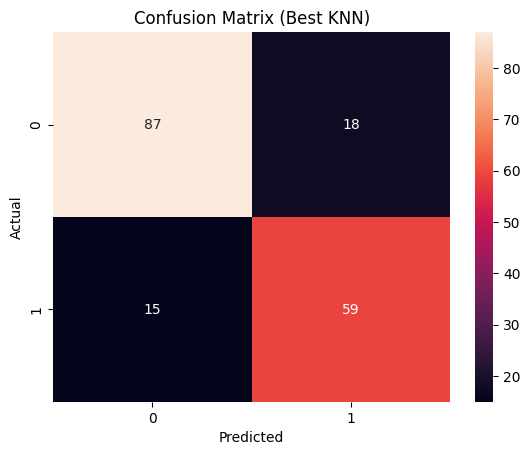

In [ ]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d')
plt.title("Confusion Matrix (Best KNN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84       105
           1       0.77      0.80      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

